### ***Goal:*** Create a mini package that can solve 1D reaction-diffusion PDEs of the form 
\begin{equation}
\begin{cases}
      & \hspace{-2mm} u_t = Du_{xx} + f(u)   \qquad \text{for } \; x \in [0,L], \; t \in [0,T], \\[2pt]
      & \hspace{-2mm} u_x(0,t) = u_x(L,t) = 0    \\[2pt]
      & \hspace{-2mm} u(x,0) = u^0(x) 
\end{cases}
\end{equation}

using three different types of Finite Difference methods
- Implicit
- Explicit
- Implicit-Explicit (IMEX)

In [1]:
using LinearAlgebra, UnPack, OrdinaryDiffEq, CairoMakie, LaTeXStrings, NBInclude, Statistics

In [2]:
@nbinclude("../cell_models/migration/model_utils/set_makie_defaults.ipynb")

In [3]:
#Inputs:
"""Inputs"""
#N    :: number of sub-intervals
#a,b  :: endpoints of the domain (a < b) 
#t0   :: initial time 
#tf   :: final time 
#D    :: diffusion coefficient
#f    :: reaction term 
#u0   :: initial condition 
"""""""

In [2]:
function discrete_laplacian_matrix_noflux(;N::Int)
    """
    This function computes the discrete Laplacian matrix with no-flux boundary conditions for the given number of sub-intervals N. 
    1st row of L     = (-2, 2, 0, ..., 0)
    ith row of L     = (0,..., 1,-2,1,...0)   (-2 in the ith position)
    (N+1)th row of L = (0,...,0, 2, -2)    

    Parameters
    ----------
    N :: number of sub-intervals
  
    Returns
    -------
    L :: (N+1)x(N+1) discrete Laplacian stencil matrix 
    """
    
    @assert N ≥ 2 "Invalid number of sub-intervals: must have N ≥ 2; passed N = $N."   
   
    L = Tridiagonal(ones(N), -2.0*ones(N+1), ones(N))
    L[1,2] = L[end, end-1] = 2.0                        #Modify first and last rows based on no-flux BCs 
    return L
end 

discrete_laplacian_matrix_noflux (generic function with 1 method)

In [167]:
function solve_explicit(;N::Int, D::Real, xspan::Tuple{<:Real,<:Real}, tspan::Tuple{<:Real,<:Real}, Δt::Real, u0::Function)
    """
    PARAMETERS
    ----------
    N  :: number of sub-intervals
    D  :: diffusion coefficient
    xspan  :: spatial domain (an interval) 
    tspan :: time interval over which to integrate 
    Δt :: step size for time 
    u0 :: initial condition function 
    """
    
    a, b = xspan        #endpoints of spatial domain
    t0, tf = tspan      #endpoints of time interval 

    #Input validation 
    @assert N ≥ 2 "Invalid number of sub-intervals: must have N ≥ 2; passed N = $N."   
    @assert D ≥ 0 "Invalid diffusion coefficient: must have D ≥ 0; Passed D = $D."   
    @assert a < b "Invalid interval. Must have a < b. Passed a = $a, b = $b." 
    @assert t0 < tf "Invalid interval. Must have t0 < tf. Passed t0 = $t0, tf = $tf." 
    @assert Δt > 0 "Invalid time step. Must have Δt > 0. Passed Δt = $Δt." 
    
    Δx = (b - a) / N                #mesh size 
    μ = D * Δt / (Δx)^2             #"diffusion number"   
    μ > 1/2 && println("Warning: μ  = $μ > 1/2. The method may be unstable.")
    

    M = Int(floor((tf - t0) / Δt))  #Number of time sub-intervals 
    #Given the solution at t_0 = a, we compute the solution at times t_n = t_0 + nΔt for n = 1,2,...,M, where M = ⌊(b-a)/Δt⌋
    #Note that t_M = t_0 + MΔt ≤ tf in general (t_M = tf iff (b-a)/Δt is an integer) 

    L = discrete_laplacian_matrix_noflux(;N = N)      
    A = Diagonal(ones(N+1)) +  μ*L      
    
    #Initialize matrix to store solution. (n+1)th column stores solution at nth time step (for n = 0,1,2,...,M) 
    U = zeros(N+1,M+1)    
 
    #Get the grid points at which to compute the solution (solution is computed at N+1 grid points; the +1 is b/c we include the initial condition)
    x = LinRange(a, b, N+1)
    
    #Populate the initial condition 
    U[:,1] = u0.(x)

    for n = 1:M   #n+1 ranges from 2 to M+1 (inclusive) 
        U[:,n+1] = A * U[:,n]  
    end 

    return U
end 

solve_explicit (generic function with 1 method)

In [168]:
a = 0.0
b = 1.0 
f(x) = 1.0 + cos(π*x/(b - a))
Δx, Δt, D = solve_explicit(N = 12, D = 2.0, xspan = (a, b), tspan = (0.0, 1.0), Δt = 0.001, u0 = f)

Δx = 0.08333333333333333, Δt = 0.1, D = 2.0


(Δx = 0.08333333333333333, Δt = 0.1, D = 2.0)

In [173]:
 μ = D * 0.001 / (Δx)^2             #"diffusion number" 

0.28800000000000003

In [170]:
D * Δt

0.2

In [161]:
#Step 3: Construct the ODE function
function semi_implicit_system!(du, u, p, t) 
    """
    du :: derivative vector (length N+1)
    u  :: state vector (length N+1)
    p  :: parameter tuple 
    t  :: time 
    """
    @unpack A, C, μ, f = p      #A is an (N+1)x(N+1) matrix; μ = D/h^2; f is the nonlinear term in the PDE 
    mul!(du, A, u)              #Compute A*u and store result in du (no allocations) 
    @. du = μ * du + C*(u-1.0)  #Multiply by μ and add the non-linear term f(u) (update du in-place) 
    return nothing
end 

semi_implicit_system! (generic function with 1 method)

In [163]:
#Constants 
N = 100             #number of sub-intervals 
L = 1.0             #Length of domain 
h = L/N             #mesh width (space) 
x = collect(0:h:L)  #grid points 

D = 0.1                  #diffusion constant 
C = D*(π/L)^2 - 1.0

#Create tridiagonal matrix A 
dl = du = ones(N)
d = -2 .* ones(N+1)
A = Tridiagonal(dl, d, du)
A[1,2] = A[end, end-1] = 2.0   #Adjust the first and last rows (corresponds to no-flux boundary conditions) 

2.0

In [263]:
#Initial condition function 
u0(x) = 1.0 + cos(π*x/L)

t0 = 0.0
tf = 3.0 
μ = D/h^2 
p = (A = A, C = C, μ = μ, f = f)
prob = ODEProblem(semi_implicit_system!, u0.(x), (t0, tf), p);

In [265]:
tvals = LinRange(t0, tf, 10)
@time sol = solve(prob, Tsit5(), abstol = 1e-3, reltol = 1e-3, saveat = tvals);
uvals = sol.u 
tvals = sol.t;

  0.011596 seconds (120 allocations: 28.531 KiB)


In [267]:
#Compare numerical solution with exact solution
function u_exact(x,t,L)
   return 1.0 + exp(-t)*cos(π*x/L)
end 

u_exact (generic function with 2 methods)

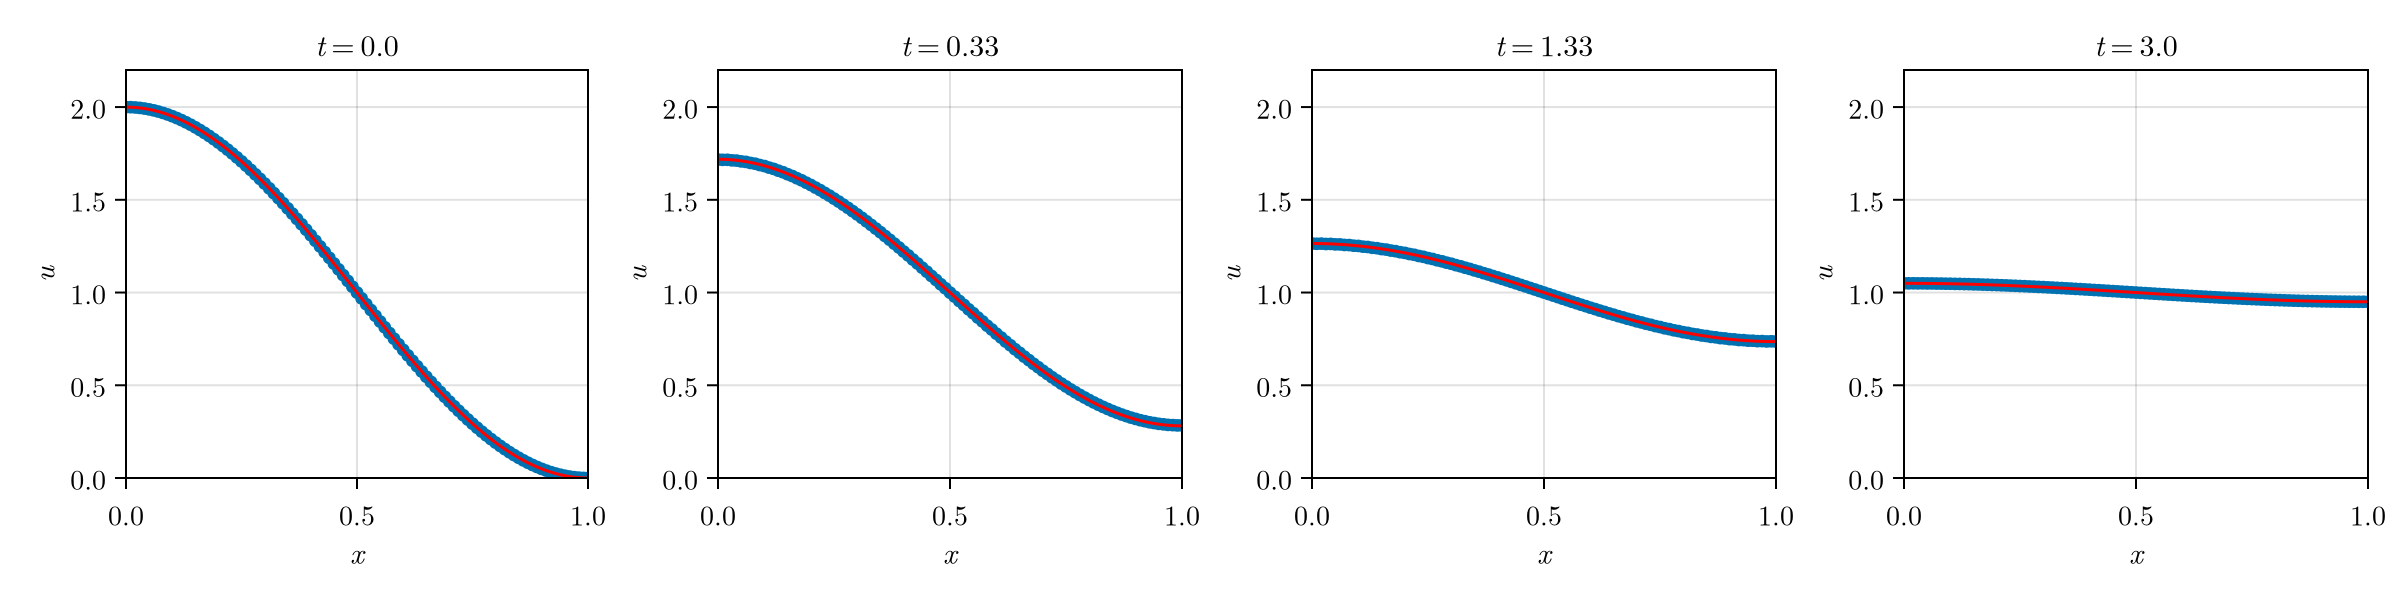

CairoMakie.Screen{IMAGE}


In [275]:
fig = Figure(size = (1200,300))
i = 1
t = round((tvals[i]), digits = 2)
ax1 = Axis(fig[1,1], xlabel = L"x", ylabel = L"u", title = L"t =  %$(tvals[i])", xlabelsize = 15, ylabelsize = 15, titlesize = 15, limits = (0,L,0,2.2))
scatter!(ax1, x, uvals[i])
lines!(ax1, x, u_exact.(x, t, L), color = :red)

i = 2 
t = round((tvals[i]), digits = 2)
ax2 = Axis(fig[1,2], xlabel = L"x", ylabel = L"u", title = L"t =  %$t", xlabelsize = 15, ylabelsize = 15, titlesize = 15, limits = (0,L,0,2.2))
scatter!(ax2, x, uvals[i])
lines!(ax2, x, u_exact.(x, t, L), color = :red)

i = 5 
t = round((tvals[i]), digits = 2)
ax3 = Axis(fig[1,3], xlabel = L"x", ylabel = L"u", title = L"t =  %$t", xlabelsize = 15, ylabelsize = 15, titlesize = 15, limits = (0,L,0,2.2))
scatter!(ax3, x, uvals[i])
lines!(ax3, x, u_exact.(x, t, L), color = :red)

t = round((tvals[end]), digits = 2)
ax4 = Axis(fig[1,4], xlabel = L"x", ylabel = L"u", title = L"t =  %$t", xlabelsize = 15, ylabelsize = 15, titlesize = 15,  limits = (0,L,0,2.2))
scatter!(ax4, x, uvals[end])
lines!(ax4, x, u_exact.(x, t, L), color = :red)

display(fig)

In [271]:
#Compute the errors at each time value 
errors = zero(tvals)
M = length(tvals)
errors = [maximum(abs.(uvals[i] .- u_exact.(x, tvals[i], L))) for i=1:length(tvals)];
# for i=1:length(tvals)
#     u_approx = uvals[i]     
#     u_true = u_exact.(x,tvals[i])
#     errors_l1[i] = mean(abs.(u_approx .- u_true))
# end

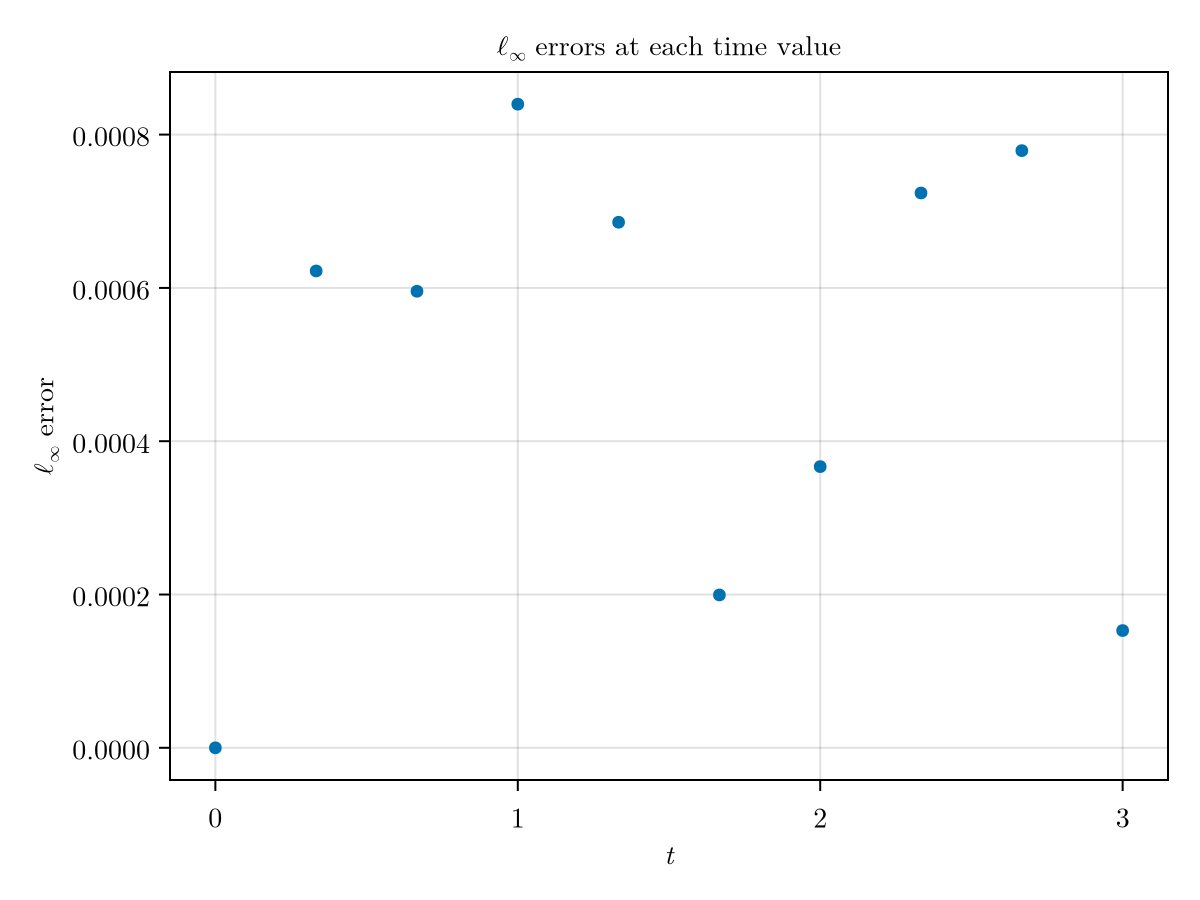

CairoMakie.Screen{IMAGE}


In [273]:
fig_err = Figure(scale = (400,400))
ax_err = Axis(fig_err[1,1], xlabel = L"t", ylabel = L"ℓ_{∞} \text{ error}", title = L"ℓ_{∞} \textrm{ errors at each time value}")
scatter!(ax_err, tvals, errors)
display(fig_err)